[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/josterri/predicting-the-next-words-notebooks/blob/pilot/ch03_workbook.ipynb)

# Classical language models

A bigram model predicts a word from the word before it. Its probabilities
come from counts of words and word pairs in the first chapters of Pride and
Prejudice.

In [1]:
#@title Setup: run this cell first
import math
import os
import re
import urllib.request
from collections import Counter

import matplotlib.pyplot as plt
import numpy as np
from IPython.display import Markdown, display

MIRROR_REF = "pilot"
TEXT_URL = f"https://raw.githubusercontent.com/josterri/predicting-the-next-words-notebooks/{MIRROR_REF}/data/pride_and_prejudice.txt"
N_MAX = 4
START = N_MAX - 1


def load_novel():
    """Pride and Prejudice as lowercase word tokens, one list per chapter."""
    if os.environ.get("PNW_TEXT"):
        text = open(os.environ["PNW_TEXT"], encoding="utf-8").read()
    else:
        text = urllib.request.urlopen(TEXT_URL).read().decode("utf-8")
    chapters = re.split(r"(?m)^CHAPTER [IVXLC]+\.$", text)[1:]
    return [re.findall(r"[a-z]+(?:'[a-z]+)*", c.lower().replace("’", "'")) for c in chapters]


def prepare(train_chapters, test_chapters):
    """Training tokens, test tokens with unknown words as <unk>, and V."""
    train = [w for c in train_chapters for w in c]
    vocab = set(train) | {"<unk>"}
    test = [w if w in vocab else "<unk>" for c in test_chapters for w in c]
    return train, test, len(vocab)


def ngram_counts(tokens, n_max):
    """counts[n][g] is how often the n-gram g occurs; counts[0][()] is the token count."""
    counts = {0: Counter({(): len(tokens)})}
    for n in range(1, n_max + 1):
        counts[n] = Counter(tuple(tokens[i - n + 1:i + 1]) for i in range(n - 1, len(tokens)))
    return counts


def perplexity(counts, test, V, n, k):
    """Add-k perplexity of the order-n model on the test tokens; inf once a token gets probability 0."""
    assert k >= 0, "K must be 0 or more"
    log_sum = 0.0
    for i in range(START, len(test)):
        g = tuple(test[i - n + 1:i + 1])
        den = counts[n - 1][g[:-1]] + k * V
        p = (counts[n][g] + k) / den if den else 0.0
        if p == 0:
            return math.inf
        log_sum += math.log(p)
    return math.exp(-log_sum / (len(test) - START))


def pair_rows(sentence, k=0):
    """(pair, pair count, first-word count, add-k probability) for each word pair of a typed sentence."""
    #% The sentence is split by the regular expression that splits the novel, so
    #% capitals, commas and curly apostrophes give the pairs the novel counts.
    w = re.findall(r"[a-z]+(?:'[a-z]+)*", sentence.lower().replace("’", "'"))
    assert len(w) > 1, "SENTENCE needs two words or more"
    assert k >= 0, "K must be 0 or more"
    types = len(counts[1])
    rows = []
    for a, b in zip(w, w[1:]):
        c, c1 = counts[2][(a, b)], counts[1][(a,)]
        #% A first word the training chapters lack has count 0; at k = 0 its pair gets probability 0.
        den = c1 + k * types
        rows.append((f"{a} {b}", c, c1, (c + k) / den if den else 0.0))
    return rows


def sentence_probability(sentence, k=0):
    """The product of the add-k probabilities of the sentence's pairs."""
    return math.prod(r[3] for r in pair_rows(sentence, k))


def show(rows):
    """The pairs as a table and as bars of their probabilities."""
    display(Markdown("| pair | count | count of the first word | probability |\n| --- | ---: | ---: | ---: |\n"
                     + "\n".join(f"| {p} | {c:,} | {c1:,} | {q:.4f} |" for p, c, c1, q in rows)))
    fig, ax = plt.subplots(figsize=(6, 3.5))
    ax.barh(range(len(rows)), [r[3] for r in rows], tick_label=[r[0] for r in rows])
    ax.invert_yaxis()
    ax.set(xlabel="probability of the second word after the first")
    plt.show()


def compare(sentence, k):
    """Bars of each pair's probability from the counts alone (k = 0) and under add-k."""
    fig, axes = plt.subplots(1, 2, figsize=(6, 3.5), sharey=True)
    for ax, kk in zip(axes, (0, k)):
        rows = pair_rows(sentence, kk)
        ax.bar_label(ax.barh(range(len(rows)), [r[3] for r in rows], tick_label=[r[0] for r in rows]), fmt="%.3g")
        ax.set(title=f"k = {kk}", xlabel="probability")
        ax.margins(x=0.35)
        ax.xaxis.set_major_locator(plt.MaxNLocator(3))
    axes[0].invert_yaxis()
    plt.show()


chapters = load_novel()
n_train = round(0.9 * len(chapters))
train_chapters, test_chapters = chapters[:n_train], chapters[n_train:]
train, test, V = prepare(train_chapters, test_chapters)
counts = ngram_counts(train, N_MAX)
display(Markdown(f"{len(chapters)} chapters: the first {n_train} train the models, with {len(train):,} tokens "
                 f"and {len(counts[1]):,} word types, and the last {len(test_chapters)} test them."))

61 chapters: the first 55 train the models, with 110,030 tokens and 6,102 word types, and the last 6 test them.

## 1. Counting and dividing

Which pair of the novel's opening words occurs most often, and which is the
likeliest? Run the cell, then put a sentence of your own into `SENTENCE` and
run it again.

| pair | count | count of the first word | probability |
| --- | ---: | ---: | ---: |
| it is | 180 | 1,367 | 0.1317 |
| is a | 71 | 779 | 0.0911 |
| a truth | 1 | 1,785 | 0.0006 |
| truth universally | 1 | 22 | 0.0455 |
| universally acknowledged | 1 | 2 | 0.5000 |

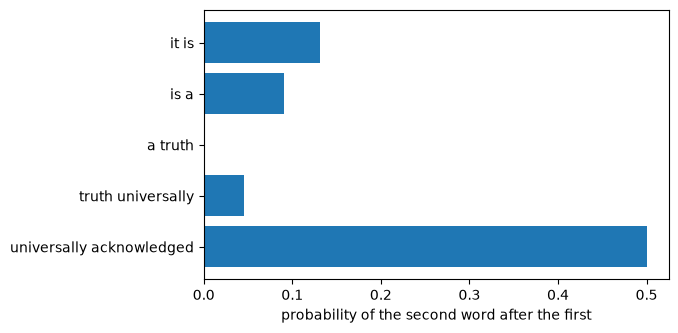

In [2]:
SENTENCE = "it is a truth universally acknowledged"
show(pair_rows(SENTENCE))

### Solution

In [3]:
rows = pair_rows(SENTENCE)
p, c, c1, q = max(rows, key=lambda r: r[3])
t, tc, tc1, tq = max(rows, key=lambda r: r[1])
display(Markdown(f"\"{p}\" is the likeliest pair: its count is {c:,} and the count of \"{p.split()[0]}\" is {c1:,}, "
                 f"a probability of {q:.2f}. The most frequent pair, \"{t}\", has count {tc:,} and \"{t.split()[0]}\" "
                 f"{tc1:,}, a probability of {tq:.2f}."))

"universally acknowledged" is the likeliest pair: its count is 1 and the count of "universally" is 2, a probability of 0.50. The most frequent pair, "it is", has count 180 and "it" 1,367, a probability of 0.13.

## 2. One unseen pair makes the sentence impossible

Run the cell: the probability of the sentence is the product of the
probabilities of its pairs. Which pair is unseen, and can the other pairs make
up for it?

| pair | count | count of the first word | probability |
| --- | ---: | ---: | ---: |
| lydia danced | 0 | 127 | 0.0000 |
| danced with | 6 | 13 | 0.4615 |
| with mr | 14 | 966 | 0.0145 |
| mr wickham | 58 | 732 | 0.0792 |

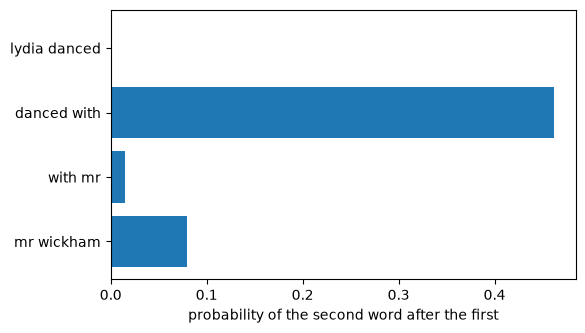

probability of the sentence: 0


In [4]:
SENTENCE = "lydia danced with mr wickham"
show(pair_rows(SENTENCE))
print(f"probability of the sentence: {sentence_probability(SENTENCE):.3g}")

### Solution

In [5]:
rows = pair_rows(SENTENCE)
unseen = [r for r in rows if r[1] == 0]
total = sentence_probability(SENTENCE)
display(Markdown(
    f"\"{unseen[0][0]}\" never occurs in the training chapters, so its probability is {unseen[0][3]:g}, and the "
    f"probability of the sentence, the product over its pairs, is {total:g} whatever the other pairs are."
    if unseen else f"Every pair of the sentence occurs in the training chapters, and its probability is {total:.3g}."))

"lydia danced" never occurs in the training chapters, so its probability is 0, and the probability of the sentence, the product over its pairs, is 0 whatever the other pairs are.

## 3. Add-one gives every pair a share

Run the cell with `K = 1`: add-one adds one to the count of every pair, seen
or unseen. The count of each first word then grows by one for every word type
of the training chapters. How many times likelier than "lydia danced" is
"danced with" now?

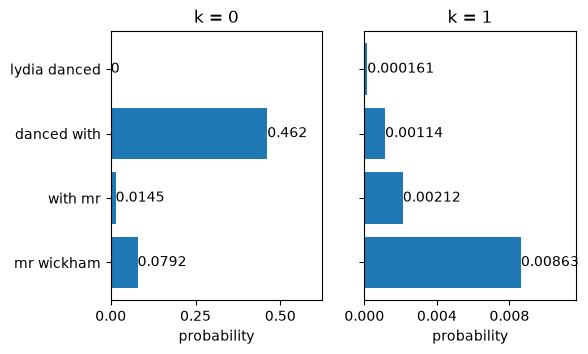

In [6]:
K = 1
SENTENCE = "lydia danced with mr wickham"
compare(SENTENCE, K)

### Solution

In [7]:
raw, smooth = pair_rows(SENTENCE), pair_rows(SENTENCE, K)
assert len(raw) > 1, "step 3 compares two pairs: SENTENCE needs three words or more"
hi = max(range(len(raw)), key=lambda i: raw[i][3])
lo = min((i for i in range(len(raw)) if i != hi), key=lambda i: raw[i][3])
a, b = smooth[hi][3], smooth[lo][3]
display(Markdown(f"At k = {K}, \"{raw[hi][0]}\" has probability {a:.3g} and \"{raw[lo][0]}\" {b:.3g}, so "
                 f"\"{raw[hi][0]}\" is {f'{a / b:.1f} times' if b else 'infinitely'} likelier. From the counts "
                 f"alone, \"{raw[hi][0]}\" has probability {raw[hi][3]:.2f}."))

At k = 1, "danced with" has probability 0.00114 and "lydia danced" 0.000161, so "danced with" is 7.1 times likelier. From the counts alone, "danced with" has probability 0.46.

## Appendix. Held-out perplexity

An n-gram model predicts a word w from its history h, the n − 1 words before
it. Add-k adds k to the count of every n-gram, seen or unseen:

P(w | h) = (count(h w) + k) / (count(h) + k·V),

where V is the number of word types, `<unk>` included; a test word the
training chapters lack becomes `<unk>`. Perplexity is the exponential of the
mean negative log probability over the N test tokens:

PP = exp(−(1/N) · Σ log P(w | h)).

A lower perplexity means the model gave the test chapters a higher probability.

Held-out perplexity on the last chapters, for k = 1, 0.1 and 0.01 and orders
n = 1 to 4:

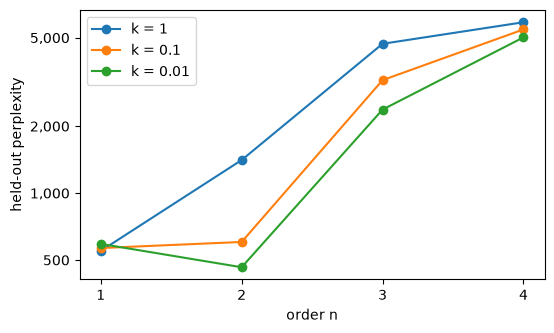

In [8]:
orders = list(range(1, N_MAX + 1))
pp = {k: [perplexity(counts, test, V, n, k) for n in orders] for k in (1, 0.1, 0.01)}
fig, ax = plt.subplots(figsize=(6, 3.5))
for k, row in pp.items():
    ax.plot(orders, row, marker="o", label=f"k = {k}")
ax.set(xlabel="order n", ylabel="held-out perplexity", xticks=orders, yscale="log")
ax.set_yticks([500, 1000, 2000, 5000], labels=["500", "1,000", "2,000", "5,000"])
ax.minorticks_off()
ax.legend()
plt.show()

**Exercise.** Set `K` to 1, 0.1, 0.01 and 0.001 in turn and rerun the cell
each time, then set `K = 0`. At which k are the bigram and the 4-gram best,
and what does `K = 0` do to the perplexity?

In [9]:
K = 0.01

for n in (2, 4):
    print(f"n = {n}, k = {K}: perplexity {perplexity(counts, test, V, n, K):,.0f}")

n = 2, k = 0.01: perplexity 464
n = 4, k = 0.01: perplexity 5,019


### Solution

In [10]:
ks = [1, 0.3, 0.1, 0.03, 0.01, 0.003, 0.001]
table = {n: dict(zip(ks, (perplexity(counts, test, V, n, k) for k in ks))) for n in (2, 4)}
for n in (2, 4):
    print(f"n = {n}: " + "  ".join(f"k={k}: {p:,.0f}" for k, p in table[n].items()))
tried = [1, 0.1, 0.01, 0.001]
best = {n: min(tried, key=table[n].get) for n in (2, 4)}
fine = min(ks, key=table[4].get)
zeros = sum(counts[2][tuple(test[i - 1:i + 1])] == 0 for i in range(START, len(test)))
display(Markdown(
    f"Of k = {', '.join(map(str, tried))}, the bigram is best at k = {best[2]} ({table[2][best[2]]:,.0f}) and the "
    f"4-gram at k = {best[4]} ({table[4][best[4]]:,.0f}). On the grid of {len(ks)} values, the 4-gram does best at "
    f"k = {fine} ({table[4][fine]:,.0f}). At k = 0, {zeros:,} test bigrams have probability zero, and the first of "
    f"them makes the perplexity infinite."))

n = 2: k=1: 1,409  k=0.3: 857  k=0.1: 603  k=0.03: 485  k=0.01: 464  k=0.003: 512  k=0.001: 623
n = 4: k=1: 5,870  k=0.3: 5,667  k=0.1: 5,448  k=0.03: 5,209  k=0.01: 5,019  k=0.003: 4,888  k=0.001: 4,905


Of k = 1, 0.1, 0.01, 0.001, the bigram is best at k = 0.01 (464) and the 4-gram at k = 0.001 (4,905). On the grid of 7 values, the 4-gram does best at k = 0.003 (4,888). At k = 0, 4,160 test bigrams have probability zero, and the first of them makes the perplexity infinite.